# Coincidencia por plantilla

En este cuaderno vas a trabajar template matching con una progresión breve, visible. Primero resolvemos un ejemplo sintético mínimo. Después repetimos la misma lógica sobre una imagen real de Messi.


## Objetivo

Comprender cómo `cv2.matchTemplate()` compara una plantilla pequeña contra una imagen más grande y cómo se recupera la mejor coincidencia.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- construir una imagen principal y una plantilla sintéticas;
- obtener un mapa de similitud;
- ubicar la coincidencia máxima;
- dibujar el rectángulo correspondiente;
- repetir el procedimiento sobre una imagen real.

## Relación con la secuencia

Este cuaderno retoma coordenadas, recortes y visualización. La diferencia es que ahora la tarea consiste en buscar una región parecida dentro de una imagen.


## Módulos que vamos a usar

- `cv2`: para hacer template matching y dibujar el rectángulo final.
- `numpy`: para construir la imagen sintética.
- `matplotlib.pyplot`: para mostrar la imagen principal, la plantilla y el resultado.
- `pathlib.Path`: para construir la ruta de la imagen real y de la plantilla real.


In [1]:
# Importamos OpenCV para aplicar template matching y dibujar resultados.
import cv2

# Importamos NumPy para construir imágenes sintéticas como arreglos.
import numpy as np

# Importamos Matplotlib para visualizar cada etapa dentro del cuaderno.
import matplotlib.pyplot as plt

# Importamos Path para trabajar con rutas de archivos de manera clara.
from pathlib import Path


## 1. Construir un ejemplo sintético mínimo

Vamos a crear una imagen principal muy simple y una plantilla que sea coherente con el patrón que queremos encontrar.

En el resultado esperable deberías ver:

- una imagen principal con un cuadrado blanco y un círculo gris;
- una plantilla pequeña con el mismo cuadrado blanco sobre fondo negro.


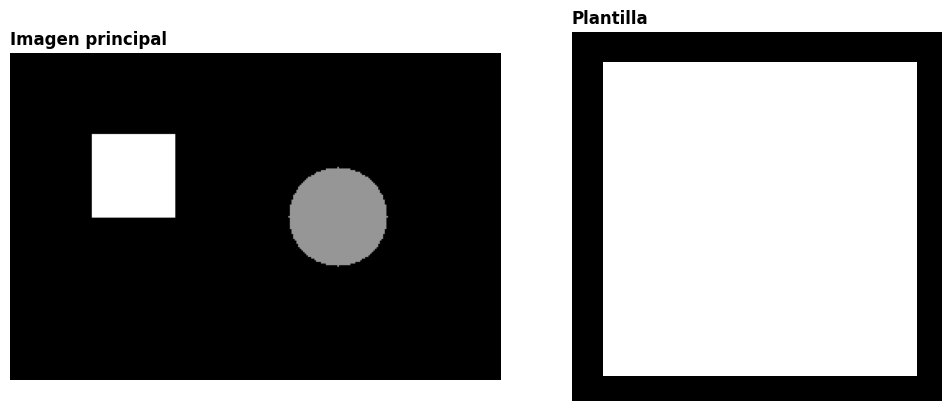

Forma de la imagen principal: (200, 300)
Forma de la plantilla: (60, 60)


In [2]:
# Creamos una imagen principal vacía, más grande.
main_image = np.zeros((200, 300), dtype=np.uint8)

# Agregamos un cuadrado blanco que funcionará como objetivo.
cv2.rectangle(main_image, (50, 50), (100, 100), 255, -1)

# Agregamos otra forma para que la imagen no tenga un único patrón.
cv2.circle(main_image, (200, 100), 30, 150, -1)

# Creamos una plantilla pequeña con el mismo patrón del cuadrado blanco.
template = np.zeros((60, 60), dtype=np.uint8)
cv2.rectangle(template, (5, 5), (55, 55), 255, -1)

# Mostramos la imagen principal y la plantilla lado a lado.
fig, ejes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ejes[0].imshow(main_image, cmap='gray')
ejes[0].set_title('Imagen principal', fontweight='bold', loc='left')
ejes[0].axis('off')
ejes[1].imshow(template, cmap='gray')
ejes[1].set_title('Plantilla', fontweight='bold', loc='left')
ejes[1].axis('off')
plt.show()

print('Forma de la imagen principal:', main_image.shape)
print('Forma de la plantilla:', template.shape)


Fijate que la plantilla no es una etiqueta abstracta, sino una imagen pequeña. Template matching no busca "un cuadrado" en general: busca una región que se parezca a esta plantilla concreta.


## 2. Buscar la región más parecida

`cv2.matchTemplate()` recorre la imagen principal y compara, posición por posición, qué tan parecida es cada zona a la plantilla dada.

En el resultado esperable deberías ver:

- la imagen principal;
- el mapa de similitud;
- la ubicación detectada marcada con un rectángulo.


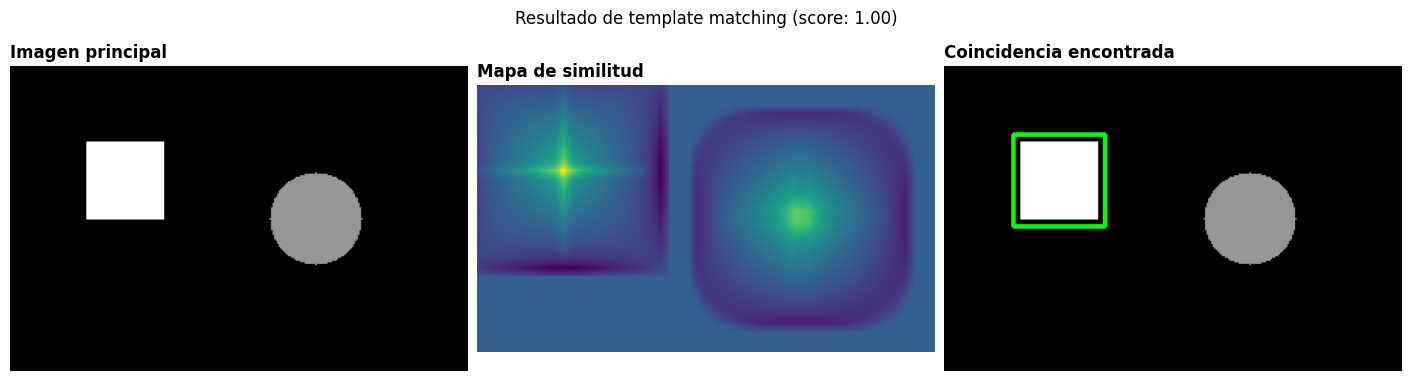

Plantilla encontrada en la posición (esquina superior izquierda): (45, 45)
Máximo score de correlación: 1.0000


In [3]:
# Recuperamos el alto y el ancho de la plantilla.
h, w = template.shape

# Aplicamos template matching con un método normalizado.
res = cv2.matchTemplate(main_image, template, cv2.TM_CCOEFF_NORMED)

# Buscamos la mejor coincidencia dentro del mapa de similitud.
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

# En este método, la mejor coincidencia está en la ubicación del máximo.
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

# Convertimos la imagen principal a color para dibujar el rectángulo.
main_image_color = cv2.cvtColor(main_image, cv2.COLOR_GRAY2BGR)
cv2.rectangle(main_image_color, top_left, bottom_right, (0, 255, 0), 2)

# Mostramos la imagen principal, el mapa de similitud y la coincidencia encontrada.
fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(main_image, cmap='gray')
ejes[0].set_title('Imagen principal', fontweight='bold', loc='left')
ejes[0].axis('off')
ejes[1].imshow(res, cmap='viridis')
ejes[1].set_title('Mapa de similitud', fontweight='bold', loc='left')
ejes[1].axis('off')
ejes[2].imshow(cv2.cvtColor(main_image_color, cv2.COLOR_BGR2RGB))
ejes[2].set_title('Coincidencia encontrada', fontweight='bold', loc='left')
ejes[2].axis('off')
plt.suptitle(f'Resultado de template matching (score: {max_val:.2f})')
plt.show()

print(f'Plantilla encontrada en la posición (esquina superior izquierda): {top_left}')
print(f'Máximo score de correlación: {max_val:.4f}')


El mapa de similitud no marca objetos por significado. Solo muestra qué posiciones se parecen más a la plantilla dada. En este ejemplo, el score alto acompaña bien lo que vemos: la coincidencia cae sobre el cuadrado blanco.


## 3. Extensión breve con Messi

Una vez entendido el caso sintético, repetimos exactamente la misma lógica sobre una imagen real. Esta parte es una extensión, no el corazón del cuaderno.


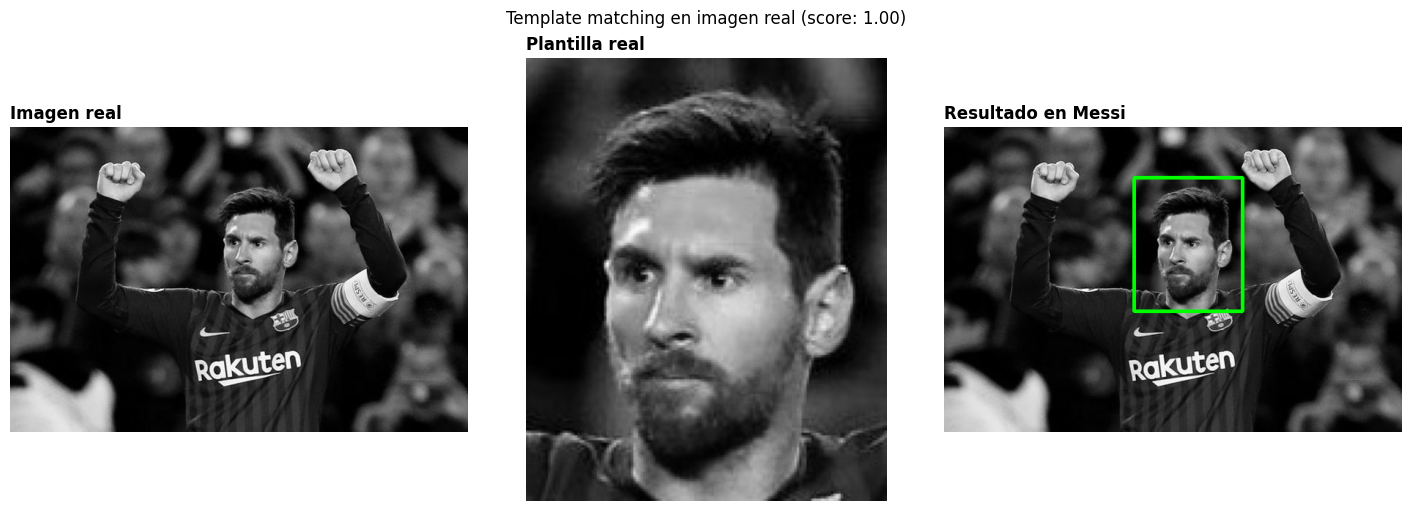

Plantilla real encontrada en: (259, 70)
Máximo score en la imagen real: 0.9996


In [4]:
# Construimos las rutas a la imagen principal y a la plantilla real.
ruta_imagen = Path('Imagenes') / 'messi.jpg'
ruta_plantilla = Path('Imagenes') / 'messi_template.jpg'

# Leemos la imagen real y la plantilla en escala de grises.
imagen_real_gris = cv2.imread(str(ruta_imagen), cv2.IMREAD_GRAYSCALE)
plantilla_real = cv2.imread(str(ruta_plantilla), cv2.IMREAD_GRAYSCALE)

if imagen_real_gris is None or plantilla_real is None:
    raise FileNotFoundError('No se pudieron leer `messi.jpg` o `messi_template.jpg`.')

# Aplicamos la misma secuencia que usamos en el ejemplo sintético.
res_real = cv2.matchTemplate(imagen_real_gris, plantilla_real, cv2.TM_CCOEFF_NORMED)
_, max_val_real, _, max_loc_real = cv2.minMaxLoc(res_real)

h_real, w_real = plantilla_real.shape
top_left_real = max_loc_real
bottom_right_real = (top_left_real[0] + w_real, top_left_real[1] + h_real)

imagen_real_color = cv2.cvtColor(imagen_real_gris, cv2.COLOR_GRAY2BGR)
cv2.rectangle(imagen_real_color, top_left_real, bottom_right_real, (0, 255, 0), 3)

# Mostramos la imagen real, la plantilla y el resultado.
fig, ejes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)
ejes[0].imshow(imagen_real_gris, cmap='gray')
ejes[0].set_title('Imagen real', fontweight='bold', loc='left')
ejes[0].axis('off')
ejes[1].imshow(plantilla_real, cmap='gray')
ejes[1].set_title('Plantilla real', fontweight='bold', loc='left')
ejes[1].axis('off')
ejes[2].imshow(cv2.cvtColor(imagen_real_color, cv2.COLOR_BGR2RGB))
ejes[2].set_title('Resultado en Messi', fontweight='bold', loc='left')
ejes[2].axis('off')
plt.suptitle(f'Template matching en imagen real (score: {max_val_real:.2f})')
plt.show()

print(f'Plantilla real encontrada en: {top_left_real}')
print(f'Máximo score en la imagen real: {max_val_real:.4f}')


En la imagen real el método es el mismo, pero la lectura ya no es tan limpia. Cambios de iluminación, textura o tamaño pueden volver más delicada la interpretación del resultado.


## Actividad breve

Probá una de estas variantes:

1. cambiá el tamaño de la plantilla sintética;
2. reemplazá `cv2.TM_CCOEFF_NORMED` por otro método;
3. elegí otra región de `messi.jpg` como plantilla.

Después respondé:

- ¿el score subió o bajó?
- ¿la región detectada siguió siendo razonable?
- ¿qué parte del método entendiste mejor después de esa prueba?


## Cierre

La coincidencia por plantilla sirve para buscar una región parecida a otra región ya conocida. Funciona especialmente bien cuando el problema está controlado. Por eso conviene enseñarla primero con un ejemplo sintético claro y recién después extenderla a una imagen real.
